In [4]:
import glob
import pandas as pd
from functools import reduce
import os
import geopandas as gpd

pasta_arabica = 'dados-brutos/arabica'
pasta_canephora = 'dados-brutos/canephora'

arquivos_arabica = glob.glob(os.path.join(pasta_arabica, '*.xlsx'))
arquivos_canephora = glob.glob(os.path.join(pasta_canephora, '*.xlsx'))

In [5]:
def trata_excel(caminho):
    
    df = pd.read_excel(caminho, header=None)
    
    linha1 = df.iloc[1]  # variável
    linha3 = df.iloc[3]  # ano
    linha4 = df.iloc[4]  # tipo
    
    linha1 = linha1.ffill()
    linha3 = linha3.ffill()
    linha4 = linha4.ffill()
    
    novas_colunas = [
        f"{nome}_{ano}_{tipo}" if pd.notna(ano) else nome
        for nome, ano, tipo in zip(linha1, linha3, linha4)
    ]
    
    df.columns = novas_colunas
    
    df = df.iloc[5:].reset_index(drop=True)
    
    df.rename(columns={df.columns[0]: 'mesorregiao'}, inplace=True)
    
    df = df.dropna(how='all')
    
    df_long = df.melt(
        id_vars=['mesorregiao'],
        var_name='variavel_ano_tipo',
        value_name='valor'
    )
    
    df_long[['variavel', 'ano', 'tipo']] = df_long['variavel_ano_tipo'].str.rsplit('_', n=2, expand=True)
    
    df_long = df_long.drop(columns=['variavel_ano_tipo'])
    df_long['valor'] = pd.to_numeric(df_long['valor'], errors='coerce')


    df_final = df_long.pivot_table(
        index=['mesorregiao', 'ano', 'tipo'],
        columns='variavel',
        values='valor'
    ).reset_index()
    
    return df_final

In [6]:
dfs_arabica = []

for arquivo in arquivos_arabica:
    
    try:
        df = trata_excel(arquivo)
        
        dfs_arabica.append(df)
        
    except Exception as e:
        print(f"Erro em {arquivo}: {e}")

dfs_canephora = []

for arquivo in arquivos_canephora:
    
    try:
        df = trata_excel(arquivo)
        
        dfs_canephora.append(df)
        
    except Exception as e:
        print(f"Erro em {arquivo}: {e}")

In [7]:
dfs_arabica[0]

variavel,mesorregiao,ano,tipo,Variável - Área colhida (Hectares)
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0
...,...,...,...,...
819,Zona da Mata (MG),2020,Café (em grão) Arábica,202022.0
820,Zona da Mata (MG),2021,Café (em grão) Arábica,190782.0
821,Zona da Mata (MG),2022,Café (em grão) Arábica,202730.0
822,Zona da Mata (MG),2023,Café (em grão) Arábica,201832.0


In [8]:
dfs_canephora[0]

variavel,mesorregiao,ano,tipo,Variável - Área colhida (Hectares)
0,Baixo Amazonas (PA),2012,Café (em grão) Canephora,255.0
1,Baixo Amazonas (PA),2013,Café (em grão) Canephora,213.0
2,Baixo Amazonas (PA),2014,Café (em grão) Canephora,138.0
3,Baixo Amazonas (PA),2015,Café (em grão) Canephora,56.0
4,Baixo Amazonas (PA),2016,Café (em grão) Canephora,60.0
...,...,...,...,...
400,Zona da Mata (MG),2020,Café (em grão) Canephora,522.0
401,Zona da Mata (MG),2021,Café (em grão) Canephora,504.0
402,Zona da Mata (MG),2022,Café (em grão) Canephora,488.0
403,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0


In [9]:
df_final_arabica = reduce(lambda left, right: left.merge(right, on=['mesorregiao', 'ano', 'tipo']), dfs_arabica)
df_final_canephora = reduce(lambda left, right: left.merge(right, on=['mesorregiao', 'ano', 'tipo']), dfs_canephora)

In [10]:
df_final = pd.concat([df_final_arabica, df_final_canephora], ignore_index=True)

In [11]:
df_final['Variável - Valor da produção (Mil Reais)'] = df_final['Variável - Valor da produção (Mil Reais)'] * 1000
df_final['Variável - Quantidade produzida (Toneladas)'] = df_final['Variável - Quantidade produzida (Toneladas)'] * 1000

In [12]:
df_final.rename(columns={'Variável - Valor da produção (Mil Reais)': 'Variável - Valor da produção (Reais)',
                         'Variável - Quantidade produzida (Toneladas)': 'Variável - Quantidade produzida (Quilogramas)'
                         }, inplace=True)

In [13]:
df_final

variavel,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais)
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0,2.0,2000.0,1000.0,36000.0
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0,2733.0,1075000.0,393.0,3851000.0
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0,2615.0,771000.0,295.0,2439000.0
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1618000.0
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0,2265.0,867000.0,383.0,2325000.0
...,...,...,...,...,...,...,...,...
1224,Zona da Mata (MG),2020,Café (em grão) Canephora,522.0,522.0,1233000.0,2362.0,6623000.0
1225,Zona da Mata (MG),2021,Café (em grão) Canephora,504.0,504.0,1069000.0,2121.0,8679000.0
1226,Zona da Mata (MG),2022,Café (em grão) Canephora,488.0,488.0,1340000.0,2746.0,15327000.0
1227,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0,498.0,1181000.0,2371.0,10643000.0


In [14]:
caminho_shapefile = "dados-brutos/centroides/BR_Mesorregioes_2022/BR_Mesorregioes_2022.shp"
mesorregioes = gpd.read_file(caminho_shapefile)
mesorregioes['centroide'] = mesorregioes.geometry.centroid
mesorregioes['latitude'] = mesorregioes.centroide.y
mesorregioes['longitude'] = mesorregioes.centroide.x

mesorregioes['NM_MESO'] = mesorregioes['NM_MESO'] + ' (' + mesorregioes['SIGLA_UF'] + ')'

mesorregioes = mesorregioes[['NM_MESO', 'latitude', 'longitude']]

C:\Users\plles\AppData\Local\Temp\ipykernel_56896\726320708.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mesorregioes['centroide'] = mesorregioes.geometry.centroid


In [15]:
mesorregioes.rename(columns={'NM_MESO': 'mesorregiao'}, inplace=True)
mesorregioes.head()

,mesorregiao,latitude,longitude
0,Madeira-Guaporé (RO),-10.302659,-64.055361
1,Leste Rondoniense (RO),-11.406309,-61.861723
2,Vale do Juruá (AC),-8.539777,-71.773867
3,Vale do Acre (AC),-9.941532,-69.066201
4,Norte Amazonense (AM),-0.615226,-65.567522


In [16]:
df_final = df_final.merge(mesorregioes, on='mesorregiao', how='left')

In [17]:
df_final.head()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0,2.0,2000.0,1000.0,36000.0,-7.029713,-35.819545
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0,2733.0,1075000.0,393.0,3851000.0,-8.510505,-36.416511
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0,2615.0,771000.0,295.0,2439000.0,-8.510505,-36.416511
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1618000.0,-8.510505,-36.416511
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0,2265.0,867000.0,383.0,2325000.0,-8.510505,-36.416511


In [18]:
def trata_temperatura(caminho):

    cabecalho = pd.read_csv(
        caminho,
        sep=';',
        encoding='latin1',
        nrows=8,
        header=None
    )


    latitude = cabecalho.iloc[4, 1]
    longitude = cabecalho.iloc[5, 1]
    altitude  = cabecalho.iloc[6, 1]


    df = pd.read_csv(
    caminho,
    sep=';',
    encoding='latin1',
    skiprows=8  
    )

    df['latitude'] = latitude
    df['longitude'] = longitude
    df['altitude'] = altitude

    nome_arquivo = os.path.basename(caminho)

    partes = nome_arquivo.split('_')

    regiao = partes[1]
    uf = partes[2]
    cidade = partes[4]
    ano = partes[5]

    df['regiao'] = regiao
    df['uf'] = uf
    df['cidade'] = cidade
    df['ano'] = ano

    if ano[-4:] in ['2019', '2020', '2021', '2022', '2023', '2024']:
        df['DATA (YYYY-MM-DD)'] = pd.to_datetime(df['Data']).dt.date

    df = df[['DATA (YYYY-MM-DD)', 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
          'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)', 'UMIDADE RELATIVA DO AR, HORARIA (%)', 
          'regiao', 'uf', 'cidade', 'ano', 'latitude', 'longitude', 'altitude']]
    
    cols = [
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
        'altitude'
    ]

    for col in cols:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.'),
            errors='coerce'
        )

    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].astype(float)
    df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'] = df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'].astype(float)
    df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'] = df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'].astype(float)
    df['altitude'] = df['altitude'].astype(float)

    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].clip(lower=0)
    df = df[df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'] >= -100]
    df = df[df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'] >= -100]
    df = df[df['UMIDADE RELATIVA DO AR, HORARIA (%)'] >= 0]
    df = df[df['UMIDADE RELATIVA DO AR, HORARIA (%)'] <= 100]
    df = df[df['altitude'] >= 0]

    df_diario = df.groupby('DATA (YYYY-MM-DD)').agg({
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'max',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'min',
        'UMIDADE RELATIVA DO AR, HORARIA (%)': 'mean',
        'altitude': 'mean'
    }).reset_index()


    df_diario['DATA (YYYY-MM-DD)'] = pd.to_datetime(df_diario['DATA (YYYY-MM-DD)'])
    mask = df_diario['DATA (YYYY-MM-DD)'].dt.month >= 10
    soma = df_diario.loc[mask, 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].sum()
    df_diario['precipitacao_floracao'] = soma

    df_final = df_diario.agg({
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'mean',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'mean',
        'UMIDADE RELATIVA DO AR, HORARIA (%)': 'mean',
        'precipitacao_floracao': 'mean',
        'altitude': 'mean'
    }).to_frame().T


    df_final['regiao'] = df['regiao'].iloc[0]
    df_final['uf'] = df['uf'].iloc[0]
    df_final['cidade'] = df['cidade'].iloc[0]
    df_final['ano'] = df['ano'].iloc[0]
    df_final['latitude'] = df['latitude'].iloc[0]
    df_final['longitude'] = df['longitude'].iloc[0]

    df_final = df_final.rename(columns={
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'precipitacao_total (mm)',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'temperatura_maxima (°C)',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'temperatura_minima (°C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'umidade_relativa (%)'})

    df_final['ano'] = pd.to_datetime(df_final['ano'], format='%d-%m-%Y')
    df_final['ano'] = df_final['ano'].dt.year

    return df_final

In [19]:
dfs = []

for root, dirs, files in os.walk('dados-brutos/dados-climaticos'):
    for file in files:
        if file.endswith('.CSV'):
            
            caminho = os.path.join(root, file)
            
            try:
                df = trata_temperatura(caminho)
                
                if df is not None:
                    dfs.append(df)
            
            except Exception as e:
                print(f"Erro em {caminho}: {e}")

df_temp = pd.concat(dfs, ignore_index=True)

Erro em dados-brutos/dados-climaticos\2012\2012\INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2012_A_31-12-2012.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2012\2012\INMET_N_PA_A234_TUCUMA_01-01-2012_A_31-12-2012.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2013\INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2013\INMET_N_PA_A234_TUCUMA_01-01-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2013\INMET_SE_MG_F501_BELO HORIZONTE - CERCADINHO_27-12-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2014\2014\INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2014_A_31-12-2014.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2014\2014\INMET_N_PA_A234_TUCUMA_01-0

In [20]:
df_temp.tail()

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude
6745,286.6,22.911268,18.392254,91.048732,38.8,34.36,S,SC,Laguna - Farol de Santa Marta,2024,"-28,60444444","-48,81333333"
6746,1675.8,25.382240,16.835792,85.811543,147.8,2.00,S,SC,ARARANGUA,2024,"-28,931353","-49,49792"
6747,2104.4,25.283014,17.926027,82.882414,631.4,9.76,S,SC,ITAJAI,2024,"-26,95083333","-48,76194444"
6748,891.4,28.567910,19.239552,75.571464,0.0,679.00,S,SC,CHAPECO,2024,"-27,0853111","-52,6357111"
6749,1899.8,23.781967,13.808470,78.273432,503.2,963.00,S,SC,CAMPOS NOVOS,2024,"-27,3886111","-51,21583333"


In [21]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c 

In [22]:
mesorregioes

,mesorregiao,latitude,longitude
0,Madeira-Guaporé (RO),-10.302659,-64.055361
1,Leste Rondoniense (RO),-11.406309,-61.861723
2,Vale do Juruá (AC),-8.539777,-71.773867
3,Vale do Acre (AC),-9.941532,-69.066201
4,Norte Amazonense (AM),-0.615226,-65.567522
...,...,...,...
134,Norte Goiano (GO),-13.895544,-48.347095
135,Centro Goiano (GO),-15.981377,-49.778494
136,Leste Goiano (GO),-15.279044,-47.512262
137,Sul Goiano (GO),-17.743173,-50.504003


In [23]:
cols = [
        'latitude',
        'longitude'
    ]

for col in cols:
    df_temp[col] = pd.to_numeric(
        df_temp[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

df_temp['latitude'] = df_temp['latitude'].astype(float)
df_temp['longitude'] = df_temp['longitude'].astype(float)

In [24]:
df_temp_teste = df_temp[df_temp['ano'] == 2019]

In [25]:
df_temp_teste

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude
3518,1369.4,28.050685,16.936438,64.033021,502.2,1160.96,CO,DF,BRASILIA,2019,-15.789343,-47.925756
3519,1466.2,28.323691,18.042424,61.651188,497.8,1143.00,CO,DF,BRAZLANDIA,2019,-15.599722,-48.131111
3520,1369.6,29.571154,15.793407,66.829497,630.6,1030.36,CO,DF,AGUAS EMENDADAS,2019,-15.596491,-47.625801
3521,1247.8,29.413425,16.670959,64.407435,456.2,990.00,CO,DF,GAMA (PONTE ALTA),2019,-15.935278,-48.137500
3522,1187.4,28.988493,17.292603,67.867600,543.2,1043.00,CO,DF,PARANOA (COOPA-DF),2019,-16.012222,-47.557417
...,...,...,...,...,...,...,...,...,...,...,...,...
4101,829.0,25.970674,17.606452,85.016268,102.0,2.00,S,SC,ARARANGUA,2019,-28.931353,-49.497920
4102,1587.6,25.850685,17.919452,83.017808,376.0,9.76,S,SC,ITAJAI,2019,-26.950924,-48.762031
4103,1296.8,22.207647,12.949118,92.295600,240.6,881.00,S,SC,RANCHO QUEIMADO,2019,-27.678507,-49.042027
4104,1409.4,25.073101,15.254747,72.083480,530.2,680.00,S,SC,CHAPECO,2019,-27.955278,-52.635556


In [26]:
def achar_microrregiao(lat_est, lon_est, df_centroides):
    menor_distancia = float('inf')
    microrregiao_mais_proxima = None
    
    for _, row in df_centroides.iterrows():
        dist = haversine(lat_est, lon_est, row['latitude'], row['longitude'])
        
        if dist < menor_distancia:
            menor_distancia = dist
            microrregiao_mais_proxima = row['mesorregiao']
    
    return microrregiao_mais_proxima, menor_distancia


# Aplica para todas as estações
df_temp_teste['mesorregiao'] = df_temp_teste.apply(
    lambda row: achar_microrregiao(row['latitude'], row['longitude'], mesorregioes)[0],
    axis=1
)

print(mesorregioes)

                mesorregiao   latitude  longitude
0      Madeira-Guaporé (RO) -10.302659 -64.055361
1    Leste Rondoniense (RO) -11.406309 -61.861723
2        Vale do Juruá (AC)  -8.539777 -71.773867
3         Vale do Acre (AC)  -9.941532 -69.066201
4     Norte Amazonense (AM)  -0.615226 -65.567522
..                      ...        ...        ...
134       Norte Goiano (GO) -13.895544 -48.347095
135      Centro Goiano (GO) -15.981377 -49.778494
136       Leste Goiano (GO) -15.279044 -47.512262
137         Sul Goiano (GO) -17.743173 -50.504003
138   Distrito Federal (DF) -15.781166 -47.796851

[139 rows x 3 columns]


In [27]:
df_temp_teste

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude,mesorregiao
3518,1369.4,28.050685,16.936438,64.033021,502.2,1160.96,CO,DF,BRASILIA,2019,-15.789343,-47.925756,Distrito Federal (DF)
3519,1466.2,28.323691,18.042424,61.651188,497.8,1143.00,CO,DF,BRAZLANDIA,2019,-15.599722,-48.131111,Distrito Federal (DF)
3520,1369.6,29.571154,15.793407,66.829497,630.6,1030.36,CO,DF,AGUAS EMENDADAS,2019,-15.596491,-47.625801,Distrito Federal (DF)
3521,1247.8,29.413425,16.670959,64.407435,456.2,990.00,CO,DF,GAMA (PONTE ALTA),2019,-15.935278,-48.137500,Distrito Federal (DF)
3522,1187.4,28.988493,17.292603,67.867600,543.2,1043.00,CO,DF,PARANOA (COOPA-DF),2019,-16.012222,-47.557417,Distrito Federal (DF)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4101,829.0,25.970674,17.606452,85.016268,102.0,2.00,S,SC,ARARANGUA,2019,-28.931353,-49.497920,Sul Catarinense (SC)
4102,1587.6,25.850685,17.919452,83.017808,376.0,9.76,S,SC,ITAJAI,2019,-26.950924,-48.762031,Vale do Itajaí (SC)
4103,1296.8,22.207647,12.949118,92.295600,240.6,881.00,S,SC,RANCHO QUEIMADO,2019,-27.678507,-49.042027,Grande Florianópolis (SC)
4104,1409.4,25.073101,15.254747,72.083480,530.2,680.00,S,SC,CHAPECO,2019,-27.955278,-52.635556,Noroeste Rio-grandense (RS)


In [28]:
df_temp = df_temp.merge(
    df_temp_teste[['mesorregiao', 'regiao', 'uf', 'cidade']],
    on=['regiao', 'uf', 'cidade'],
    how='left'
)

In [29]:
df_temp

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude,mesorregiao
0,1307.4,27.054645,16.604098,65.373758,587.8,1159.54,CO,DF,BRASILIA,2012,-15.789444,-47.925833,Distrito Federal (DF)
1,1284.0,28.527049,15.517213,67.855631,565.2,1200.00,CO,DF,AGUAS EMENDADAS,2012,-15.596389,-47.625833,Distrito Federal (DF)
2,1708.8,30.822678,17.804918,67.062033,585.8,770.00,CO,GO,GOIANIA,2012,-16.642778,-49.220000,Centro Goiano (GO)
3,685.0,29.829781,16.812842,68.223585,328.2,771.42,CO,GO,MORRINHOS,2012,-17.716667,-49.100000,Sul Goiano (GO)
4,505.4,31.284573,19.514050,62.458362,332.6,488.51,CO,GO,SAO SIMAO,2012,-18.966667,-50.616667,Sul Goiano (GO)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6745,286.6,22.911268,18.392254,91.048732,38.8,34.36,S,SC,Laguna - Farol de Santa Marta,2024,-28.604444,-48.813333,Sul Catarinense (SC)
6746,1675.8,25.382240,16.835792,85.811543,147.8,2.00,S,SC,ARARANGUA,2024,-28.931353,-49.497920,Sul Catarinense (SC)
6747,2104.4,25.283014,17.926027,82.882414,631.4,9.76,S,SC,ITAJAI,2024,-26.950833,-48.761944,Vale do Itajaí (SC)
6748,891.4,28.567910,19.239552,75.571464,0.0,679.00,S,SC,CHAPECO,2024,-27.085311,-52.635711,Noroeste Rio-grandense (RS)


In [30]:
df_temp['mesorregiao'].nunique()

139

In [31]:
mesorregioes['mesorregiao'].nunique()

139

In [32]:
df_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 6750 entries, 0 to 6749
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   precipitacao_total (mm)  6750 non-null   float64
 1   temperatura_maxima (°C)  6750 non-null   float64
 2   temperatura_minima (°C)  6750 non-null   float64
 3   umidade_relativa (%)     6750 non-null   float64
 4   precipitacao_floracao    6750 non-null   float64
 5   altitude                 6750 non-null   float64
 6   regiao                   6750 non-null   str    
 7   uf                       6750 non-null   str    
 8   cidade                   6750 non-null   str    
 9   ano                      6750 non-null   int32  
 10  latitude                 6750 non-null   float64
 11  longitude                6750 non-null   float64
 12  mesorregiao              6607 non-null   str    
dtypes: float64(8), int32(1), str(4)
memory usage: 659.3 KB


In [33]:
df_temp_agg = df_temp.groupby(['mesorregiao', 'ano']).agg({
    'precipitacao_total (mm)': 'mean',
    'temperatura_maxima (°C)': 'mean',
    'temperatura_minima (°C)': 'mean',
    'umidade_relativa (%)': 'mean',
    'precipitacao_floracao': 'mean',
    'altitude': 'mean'
}).reset_index()

In [34]:
df_temp_agg

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Agreste Alagoano (AL),2012,601.533333,30.401879,21.205324,73.892771,35.266667,196.666667
1,Agreste Alagoano (AL),2013,1007.266667,30.712952,21.571794,76.156624,224.200000,196.666667
2,Agreste Alagoano (AL),2014,1036.800000,30.174338,21.319909,78.302930,196.066667,196.666667
3,Agreste Alagoano (AL),2015,574.600000,32.988236,23.222919,71.140840,38.133333,196.666667
4,Agreste Alagoano (AL),2016,538.066667,31.911789,22.327992,65.495402,30.733333,196.666667
...,...,...,...,...,...,...,...,...
1769,Zona da Mata (MG),2020,1660.733333,29.007442,18.022448,78.142019,505.666667,463.856667
1770,Zona da Mata (MG),2021,896.600000,29.200172,17.050388,77.010000,349.800000,463.856667
1771,Zona da Mata (MG),2022,1326.733333,29.056661,17.429160,76.393595,734.600000,463.856667
1772,Zona da Mata (MG),2023,1327.266667,29.921461,18.544932,77.370603,405.400000,463.856667


In [35]:
df_temp_agg[df_temp_agg['mesorregiao'].str.contains('(SC)')]

C:\Users\plles\AppData\Local\Temp\ipykernel_56896\3514436738.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_temp_agg[df_temp_agg['mesorregiao'].str.contains('(SC)')]


,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
433,Grande Florianópolis (SC),2012,1393.00,25.562842,18.126503,77.570397,284.80,1.800
434,Grande Florianópolis (SC),2013,1601.80,24.890137,17.440822,77.828063,262.80,1.800
435,Grande Florianópolis (SC),2014,1530.20,25.803836,18.530685,78.482802,388.60,1.800
436,Grande Florianópolis (SC),2015,2275.40,25.530959,18.756438,80.173554,692.40,1.800
437,Grande Florianópolis (SC),2016,1390.00,22.229930,13.749866,80.844010,585.90,441.400
...,...,...,...,...,...,...,...,...
1705,Vale do Itajaí (SC),2020,1034.40,24.668980,15.302514,82.191869,292.95,288.365
1706,Vale do Itajaí (SC),2021,760.05,23.235632,15.737916,85.148857,76.35,288.365
1707,Vale do Itajaí (SC),2022,1171.70,26.073810,16.485651,80.541036,577.70,288.365
1708,Vale do Itajaí (SC),2023,1843.35,25.063638,16.165525,84.111455,468.25,288.365


In [36]:
df_final.head()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0,2.0,2000.0,1000.0,36000.0,-7.029713,-35.819545
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0,2733.0,1075000.0,393.0,3851000.0,-8.510505,-36.416511
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0,2615.0,771000.0,295.0,2439000.0,-8.510505,-36.416511
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1618000.0,-8.510505,-36.416511
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0,2265.0,867000.0,383.0,2325000.0,-8.510505,-36.416511


In [37]:
df_temp_agg.head()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Agreste Alagoano (AL),2012,601.533333,30.401879,21.205324,73.892771,35.266667,196.666667
1,Agreste Alagoano (AL),2013,1007.266667,30.712952,21.571794,76.156624,224.200000,196.666667
2,Agreste Alagoano (AL),2014,1036.800000,30.174338,21.319909,78.302930,196.066667,196.666667
3,Agreste Alagoano (AL),2015,574.600000,32.988236,23.222919,71.140840,38.133333,196.666667
4,Agreste Alagoano (AL),2016,538.066667,31.911789,22.327992,65.495402,30.733333,196.666667


In [38]:
df_final['ano'] = df_final['ano'].astype(int)

df_final = df_final.merge(df_temp_agg, on=['mesorregiao', 'ano'], how='left')

In [39]:
df_final

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0,2.0,2000.0,1000.0,36000.0,-7.029713,-35.819545,768.800000,28.629075,20.254114,82.511918,54.100000,559.810000
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0,2733.0,1075000.0,393.0,3851000.0,-8.510505,-36.416511,232.066667,29.143534,18.353461,70.905596,12.333333,684.486667
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0,2615.0,771000.0,295.0,2439000.0,-8.510505,-36.416511,618.066667,29.036885,18.879336,73.331692,106.800000,684.486667
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1618000.0,-8.510505,-36.416511,606.266667,28.628146,18.599447,74.939452,116.933333,684.486667
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0,2265.0,867000.0,383.0,2325000.0,-8.510505,-36.416511,403.000000,29.760529,18.845805,70.811290,57.933333,684.486667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,Zona da Mata (MG),2020,Café (em grão) Canephora,522.0,522.0,1233000.0,2362.0,6623000.0,-21.010901,-42.819740,1660.733333,29.007442,18.022448,78.142019,505.666667,463.856667
1225,Zona da Mata (MG),2021,Café (em grão) Canephora,504.0,504.0,1069000.0,2121.0,8679000.0,-21.010901,-42.819740,896.600000,29.200172,17.050388,77.010000,349.800000,463.856667
1226,Zona da Mata (MG),2022,Café (em grão) Canephora,488.0,488.0,1340000.0,2746.0,15327000.0,-21.010901,-42.819740,1326.733333,29.056661,17.429160,76.393595,734.600000,463.856667
1227,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0,498.0,1181000.0,2371.0,10643000.0,-21.010901,-42.819740,1327.266667,29.921461,18.544932,77.370603,405.400000,463.856667


In [40]:
df_final[df_final['altitude'].isna()]

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
51,Assis (SP),2021,Café (em grão) Arábica,17415.0,17432.0,28009000.0,1608.0,2.917180e+08,-22.768414,-50.121347,NaN,NaN,NaN,NaN,NaN,NaN
52,Assis (SP),2022,Café (em grão) Arábica,17420.0,17437.0,27514000.0,1579.0,3.054490e+08,-22.768414,-50.121347,NaN,NaN,NaN,NaN,NaN,NaN
77,Campinas (SP),2021,Café (em grão) Arábica,53532.0,53648.0,85049000.0,1589.0,1.254622e+09,-22.220282,-46.989825,NaN,NaN,NaN,NaN,NaN,NaN
218,Centro-Sul Paranaense (PR),2012,Café (em grão) Arábica,1.0,1.0,1000.0,1000.0,5.000000e+03,-25.487813,-51.972895,NaN,NaN,NaN,NaN,NaN,NaN
477,Norte Fluminense (RJ),2012,Café (em grão) Arábica,105.0,105.0,151000.0,1438.0,4.400000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
478,Norte Fluminense (RJ),2013,Café (em grão) Arábica,89.0,89.0,105000.0,1180.0,3.430000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
479,Norte Fluminense (RJ),2014,Café (em grão) Arábica,63.0,93.0,97000.0,1540.0,2.740000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
480,Norte Fluminense (RJ),2015,Café (em grão) Arábica,63.0,63.0,97000.0,1540.0,2.740000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
481,Norte Fluminense (RJ),2016,Café (em grão) Arábica,63.0,63.0,97000.0,1540.0,4.090000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
482,Norte Fluminense (RJ),2017,Café (em grão) Arábica,65.0,65.0,103000.0,1585.0,7.200000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df_final = df_final.sort_values(by=['mesorregiao', 'ano', 'tipo']).reset_index(drop=True)

df_final['precipitacao_total (mm)'] = df_final['precipitacao_total (mm)'].bfill()
df_final['temperatura_maxima (°C)'] = df_final['temperatura_maxima (°C)'].bfill()
df_final['temperatura_minima (°C)'] = df_final['temperatura_minima (°C)'].bfill()
df_final['umidade_relativa (%)'] = df_final['umidade_relativa (%)'].bfill()
df_final['altitude'] = df_final['altitude'].bfill()

In [42]:
df_final[df_final['altitude'].isna()]

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude


In [43]:
df_final[df_final['mesorregiao'].str.contains('Sudoeste Amazonense')]

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
904,Sudoeste Amazonense (AM),2012,Café (em grão) Canephora,108.0,131.0,108000.0,1000.0,241000.0,-5.180785,-69.35668,693.200000,32.257724,22.260976,81.921297,608.8,143.00
905,Sudoeste Amazonense (AM),2013,Café (em grão) Canephora,70.0,108.0,56000.0,800.0,168000.0,-5.180785,-69.35668,2369.000000,31.049315,22.024384,80.183440,814.0,143.00
906,Sudoeste Amazonense (AM),2014,Café (em grão) Canephora,80.0,80.0,96000.0,1200.0,266000.0,-5.180785,-69.35668,2218.600000,30.990909,22.102204,70.406612,275.2,143.00
907,Sudoeste Amazonense (AM),2015,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,137000.0,-5.180785,-69.35668,2779.400000,31.900548,22.301644,65.677770,808.0,143.00
908,Sudoeste Amazonense (AM),2016,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,137000.0,-5.180785,-69.35668,786.400000,31.425743,23.499010,71.101247,0.0,143.00
909,Sudoeste Amazonense (AM),2017,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,162000.0,-5.180785,-69.35668,96.400000,31.576667,23.525000,72.051523,NaN,121.54
910,Sudoeste Amazonense (AM),2020,Café (em grão) Canephora,31.0,31.0,37000.0,1194.0,144000.0,-5.180785,-69.35668,96.400000,31.576667,23.525000,72.051523,0.0,121.54
911,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,10.0,21.0,13000.0,1300.0,128000.0,-5.180785,-69.35668,1171.733333,31.669913,19.965564,73.463972,NaN,377.25
912,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,4.0,4.0,8000.0,2000.0,67000.0,-5.180785,-69.35668,1171.733333,31.669913,19.965564,73.463972,NaN,377.25
913,Sudoeste Amazonense (AM),2022,Café (em grão) Canephora,12.0,19.0,15000.0,1250.0,79000.0,-5.180785,-69.35668,1171.733333,31.669913,19.965564,73.463972,NaN,377.25


In [44]:
df_final['aproveitamento_colheita'] = df_final['Variável - Área colhida (Hectares)'] / df_final['Variável - Área destinada à colheita (Hectares)']

df_final['amplitude_termica'] = df_final['temperatura_maxima (°C)'] - df_final['temperatura_minima (°C)']

df_final['preco_medio_kg'] = df_final['Variável - Valor da produção (Reais)'] / df_final['Variável - Quantidade produzida (Quilogramas)']

In [45]:
df_final

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,aproveitamento_colheita,amplitude_termica,preco_medio_kg
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0,2.0,2000.0,1000.0,3.600000e+04,-7.029713,-35.819545,768.800000,28.629075,20.254114,82.511918,54.100000,559.810000,1.0,8.374962,18.000000
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0,2733.0,1075000.0,393.0,3.851000e+06,-8.510505,-36.416511,232.066667,29.143534,18.353461,70.905596,12.333333,684.486667,1.0,10.790073,3.582326
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0,2615.0,771000.0,295.0,2.439000e+06,-8.510505,-36.416511,618.066667,29.036885,18.879336,73.331692,106.800000,684.486667,1.0,10.157548,3.163424
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1.618000e+06,-8.510505,-36.416511,606.266667,28.628146,18.599447,74.939452,116.933333,684.486667,1.0,10.028699,2.334776
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0,2265.0,867000.0,383.0,2.325000e+06,-8.510505,-36.416511,403.000000,29.760529,18.845805,70.811290,57.933333,684.486667,1.0,10.914724,2.681661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,Zona da Mata (MG),2022,Café (em grão) Canephora,488.0,488.0,1340000.0,2746.0,1.532700e+07,-21.010901,-42.819740,1326.733333,29.056661,17.429160,76.393595,734.600000,463.856667,1.0,11.627501,11.438060
1225,Zona da Mata (MG),2023,Café (em grão) Arábica,201832.0,201832.0,262264000.0,1299.0,3.658570e+09,-21.010901,-42.819740,1327.266667,29.921461,18.544932,77.370603,405.400000,463.856667,1.0,11.376530,13.949951
1226,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0,498.0,1181000.0,2371.0,1.064300e+07,-21.010901,-42.819740,1327.266667,29.921461,18.544932,77.370603,405.400000,463.856667,1.0,11.376530,9.011854
1227,Zona da Mata (MG),2024,Café (em grão) Arábica,205375.0,205375.0,282595000.0,1376.0,5.693510e+09,-21.010901,-42.819740,1511.800000,30.457941,18.854546,76.623899,654.066667,463.856667,1.0,11.603395,20.147243


In [51]:
# Cria a coluna `cluster` em df_final usando KMeans com rótulos consistentes no tempo
# Estratégia: para cada `tipo`, treina 1 KMeans usando TODOS os anos juntos, e aplica em todas as linhas desse tipo.
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

N_CLUSTERS = 5
RANDOM_STATE = 42
RECOMPUTE_CLUSTER = True  # deixe True para atualizar os clusters com esta nova estratégia

if 'df_final' not in globals():
    raise NameError(
        "df_final não está definido neste kernel. "
        "Re-execute as células anteriores que constroem o df_final (leitura/merges/engenharia) e então rode esta célula."
    )

if RECOMPUTE_CLUSTER or ('cluster' not in df_final.columns):
    df_final = df_final.copy()

    # Seleciona apenas colunas numéricas como features; remove 'ano' pra não “forçar” separação temporal
    numeric_cols = df_final.select_dtypes(include='number').columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in ['ano', 'cluster']]
    if len(feature_cols) == 0:
        raise ValueError(
            "Não há colunas numéricas suficientes em df_final para fazer KMeans. "
            "(Depois dos merges/engenharia, era esperado ter variáveis numéricas.)"
        )

    # Inicializa
    df_final['cluster'] = np.nan

    # Treina 1 modelo por tipo usando todos os anos juntos (clusters comparáveis ao longo do tempo)
    for tipo, idx in df_final.groupby('tipo').groups.items():
        g = df_final.loc[idx]
        n_samples = len(g)
        if n_samples < 2:
            df_final.loc[idx, 'cluster'] = 0
            continue

        X = g[feature_cols].replace([np.inf, -np.inf], np.nan)
        X = X.dropna(axis=1, how='all')
        if X.shape[1] == 0:
            df_final.loc[idx, 'cluster'] = 0
            continue

        # Preenche faltantes com mediana do tipo (usa todos os anos desse tipo)
        X = X.fillna(X.median(numeric_only=True))

        n_clusters = min(N_CLUSTERS, n_samples)
        if n_clusters < 2:
            df_final.loc[idx, 'cluster'] = 0
            continue

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init='auto')
        labels = km.fit_predict(X_scaled)
        df_final.loc[idx, 'cluster'] = labels

    df_final['cluster'] = df_final['cluster'].astype(int)

df_final[['mesorregiao', 'ano', 'tipo', 'cluster']].head()

,mesorregiao,ano,tipo,cluster
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,4
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,4
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,4
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,4
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,4


In [52]:
# Cria df_plot a partir de df_final (para o gráfico de evolução dos clusters)
required_cols = ['mesorregiao', 'ano', 'tipo', 'cluster']
missing = [c for c in required_cols if c not in df_final.columns]
if missing:
    raise KeyError(
        "df_final não tem as colunas necessárias para o gráfico: " + ", ".join(missing) +
        ".\nDica: rode a etapa que cria a coluna 'cluster' antes desta parte."
    )

df_plot = df_final[required_cols].copy()

# Garantir tipos numéricos para pivot/ordenação
df_plot['ano'] = pd.to_numeric(df_plot['ano'], errors='coerce')
df_plot['cluster'] = pd.to_numeric(df_plot['cluster'], errors='coerce')

df_plot = df_plot.dropna(subset=['ano', 'cluster'])
df_plot['ano'] = df_plot['ano'].astype(int)
df_plot['cluster'] = df_plot['cluster'].astype(int)

df_plot.head()

,mesorregiao,ano,tipo,cluster
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,4
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,4
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,4
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,4
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,4


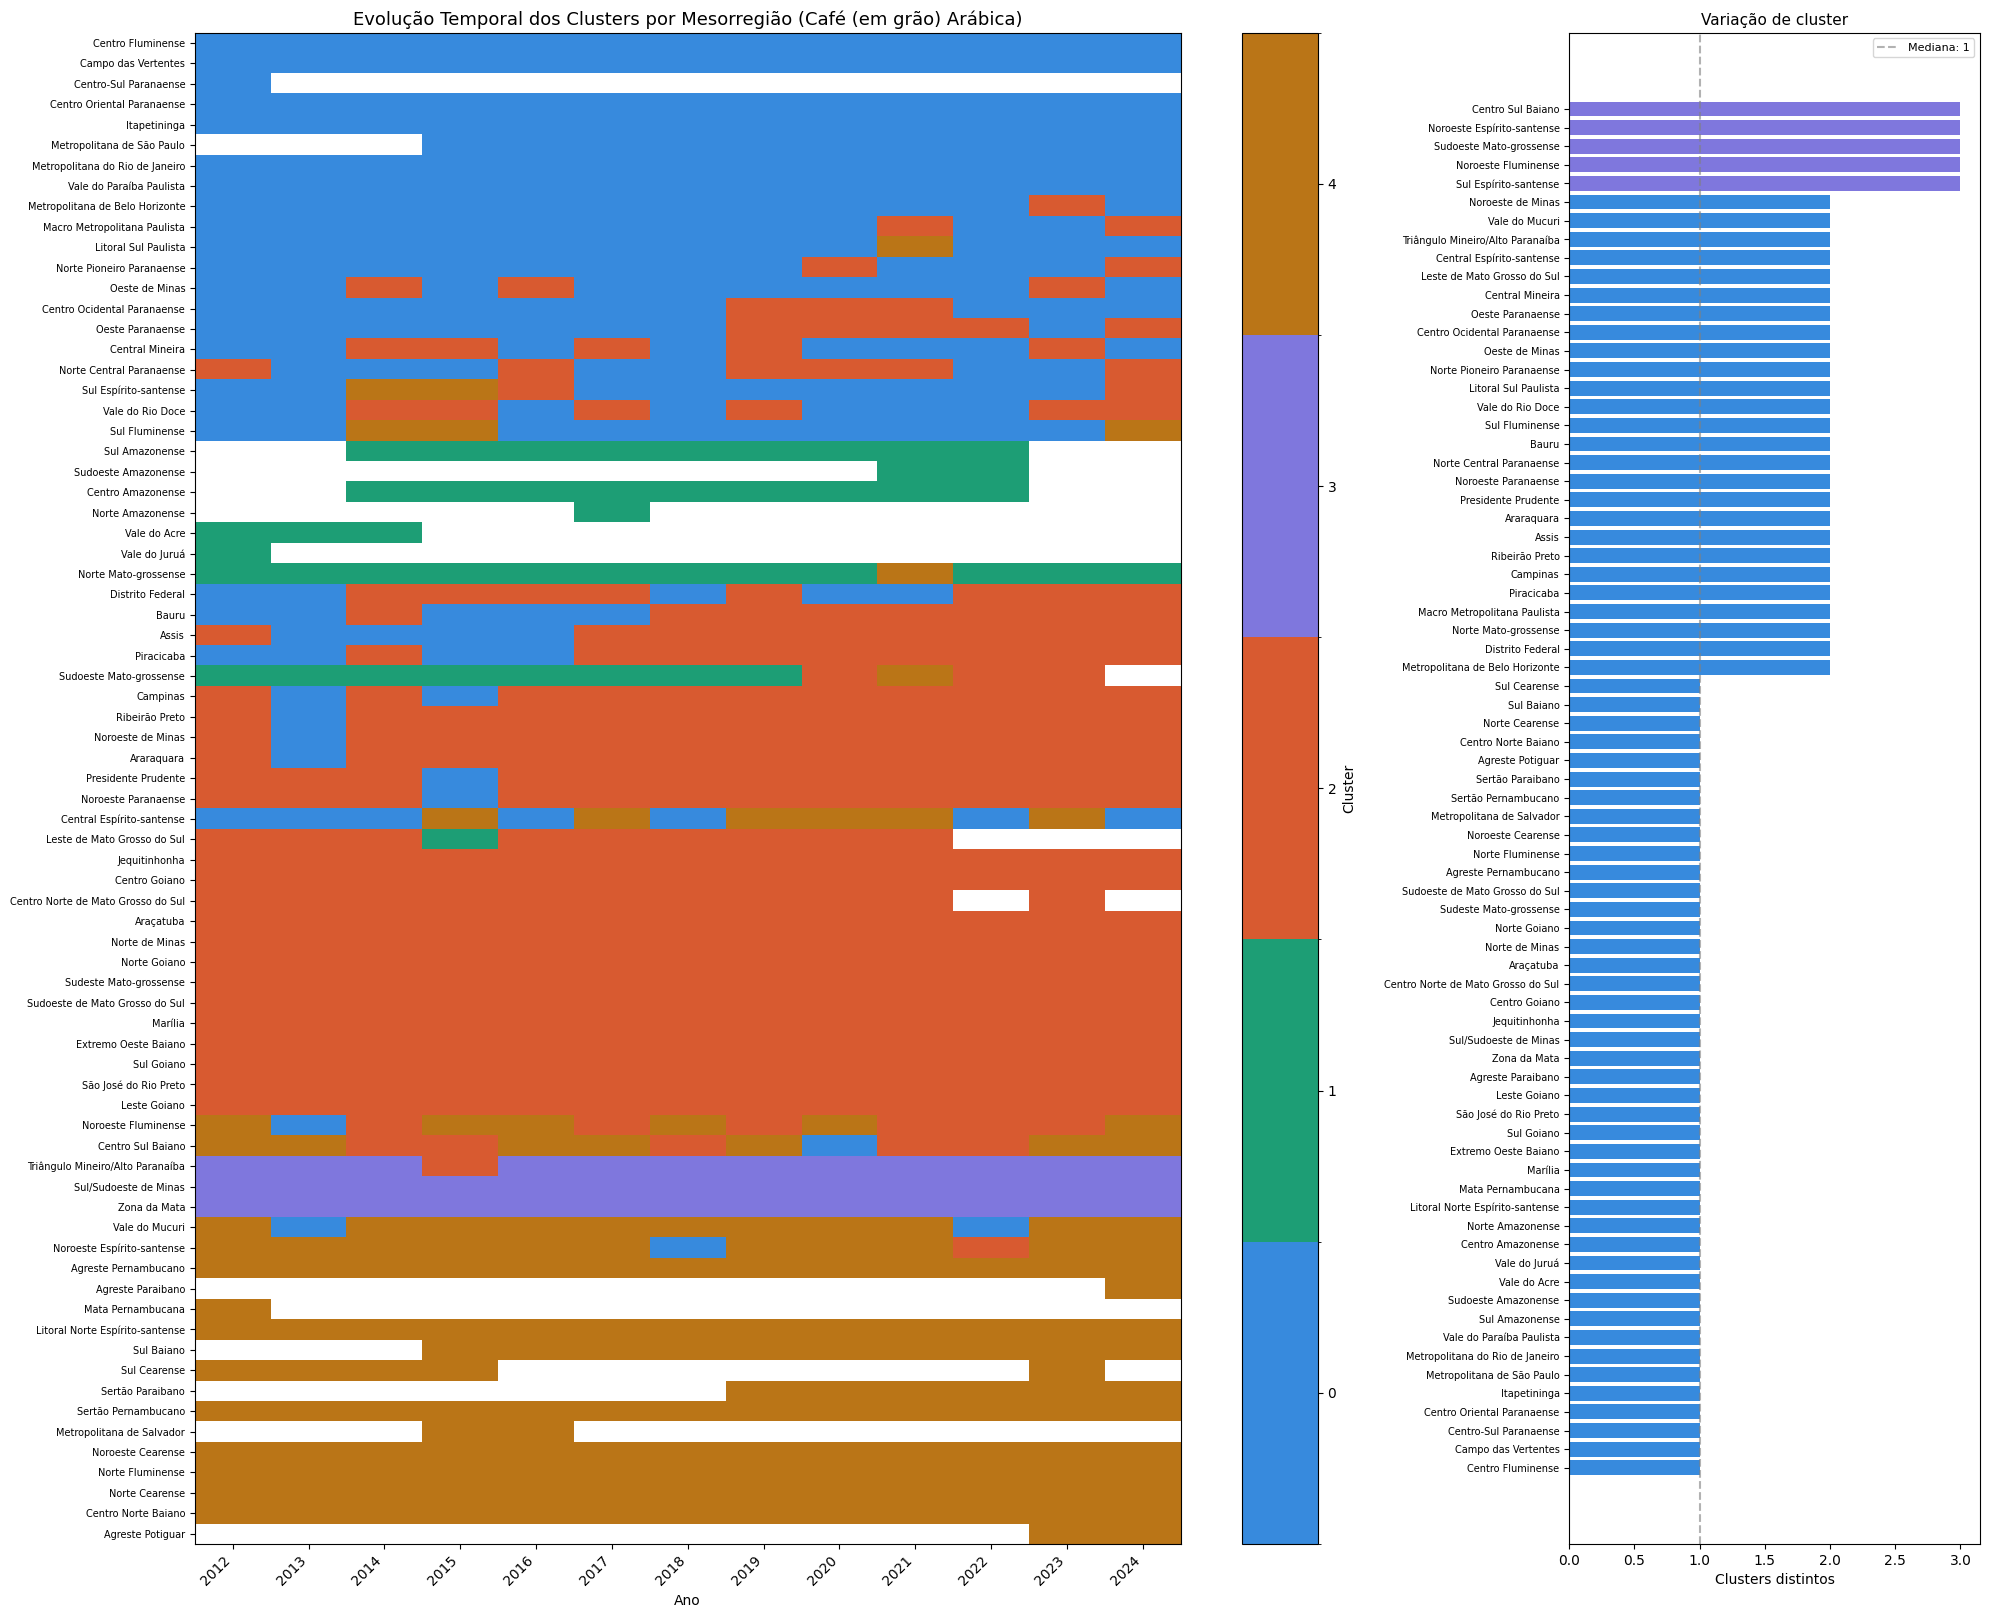


=== Top 10 mesorregiões com maior variação de cluster ===
mesorregiao
Sudoeste Mato-grossense (MT)       3
Sul Espírito-santense (ES)         3
Noroeste Fluminense (RJ)           3
Noroeste Espírito-santense (ES)    3
Centro Sul Baiano (BA)             3
Assis (SP)                         2
Vale do Mucuri (MG)                2
Noroeste de Minas (MG)             2
Oeste de Minas (MG)                2
Norte Pioneiro Paranaense (PR)     2

=== Top 10 mesorregiões mais estáveis ===
mesorregiao
Centro Fluminense (RJ)                  1
Campo das Vertentes (MG)                1
Centro-Sul Paranaense (PR)              1
Centro Oriental Paranaense (PR)         1
Itapetininga (SP)                       1
Metropolitana de São Paulo (SP)         1
Metropolitana do Rio de Janeiro (RJ)    1
Vale do Paraíba Paulista (SP)           1
Sul Amazonense (AM)                     1
Sudoeste Amazonense (AM)                1


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Se df_plot não existir (ex.: kernel reiniciado), cria a partir de df_final
if 'df_plot' not in globals():
    required_cols = ['mesorregiao', 'ano', 'tipo', 'cluster']
    missing = [c for c in required_cols if c not in df_final.columns]
    if missing:
        raise KeyError(
            "df_final não tem as colunas necessárias para o gráfico: " + ", ".join(missing) +
            ".\nDica: rode a etapa que cria a coluna 'cluster' antes desta parte."
        )
    df_plot = df_final[required_cols].copy()
    df_plot['ano'] = pd.to_numeric(df_plot['ano'], errors='coerce')
    df_plot['cluster'] = pd.to_numeric(df_plot['cluster'], errors='coerce')
    df_plot = df_plot.dropna(subset=['ano', 'cluster'])
    df_plot['ano'] = df_plot['ano'].astype(int)
    df_plot['cluster'] = df_plot['cluster'].astype(int)

if df_plot.empty:
    raise ValueError("df_plot está vazio: nada para plotar.")

cores = {"0": "#378ADD", "1": "#1D9E75", "2": "#D85A30", "3": "#7F77DD", "4": "#BA7517"}

tipos = pd.Series(df_plot["tipo"]).dropna().unique()
if len(tipos) == 0:
    raise ValueError("df_plot não tem valores válidos em 'tipo'.")
tipo_ref = tipos[0]

df_arb = df_plot[df_plot["tipo"] == tipo_ref].copy()
if df_arb.empty:
    raise ValueError(f"Não há linhas em df_plot para tipo={tipo_ref!r}.")

df_arb["cluster_num"] = df_arb["cluster"].astype(int)
pivot = df_arb.pivot_table(index="mesorregiao", columns="ano", values="cluster_num", aggfunc="first")
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(20, max(8, len(pivot) * 0.22)),
                         gridspec_kw={"width_ratios": [3, 1]})

cmap = mcolors.ListedColormap(["#378ADD", "#1D9E75", "#D85A30", "#7F77DD", "#BA7517"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = axes[0].imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm)
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels(pivot.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels([m.split(" (")[0] for m in pivot.index], fontsize=7)
axes[0].set_xlabel("Ano")
axes[0].set_title(f"Evolução Temporal dos Clusters por Mesorregião ({tipo_ref})", fontsize=13)
plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2, 3, 4], label="Cluster")

mudancas = pivot.apply(lambda row: row.nunique(), axis=1).sort_values(ascending=True)
cores_barra = ["#D85A30" if v >= 4 else "#378ADD" if v <= 2 else "#7F77DD" for v in mudancas.values]
axes[1].barh([m.split(" (")[0] for m in mudancas.index], mudancas.values, color=cores_barra)
axes[1].set_xlabel("Clusters distintos")
axes[1].set_title("Variação de cluster", fontsize=11)
axes[1].axvline(mudancas.median(), color="gray", linestyle="--", alpha=0.6,
                label=f"Mediana: {mudancas.median():.0f}")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

print("\n=== Top 10 mesorregiões com maior variação de cluster ===")
print(mudancas.sort_values(ascending=False).head(10).to_string())
print("\n=== Top 10 mesorregiões mais estáveis ===")
print(mudancas.sort_values().head(10).to_string())

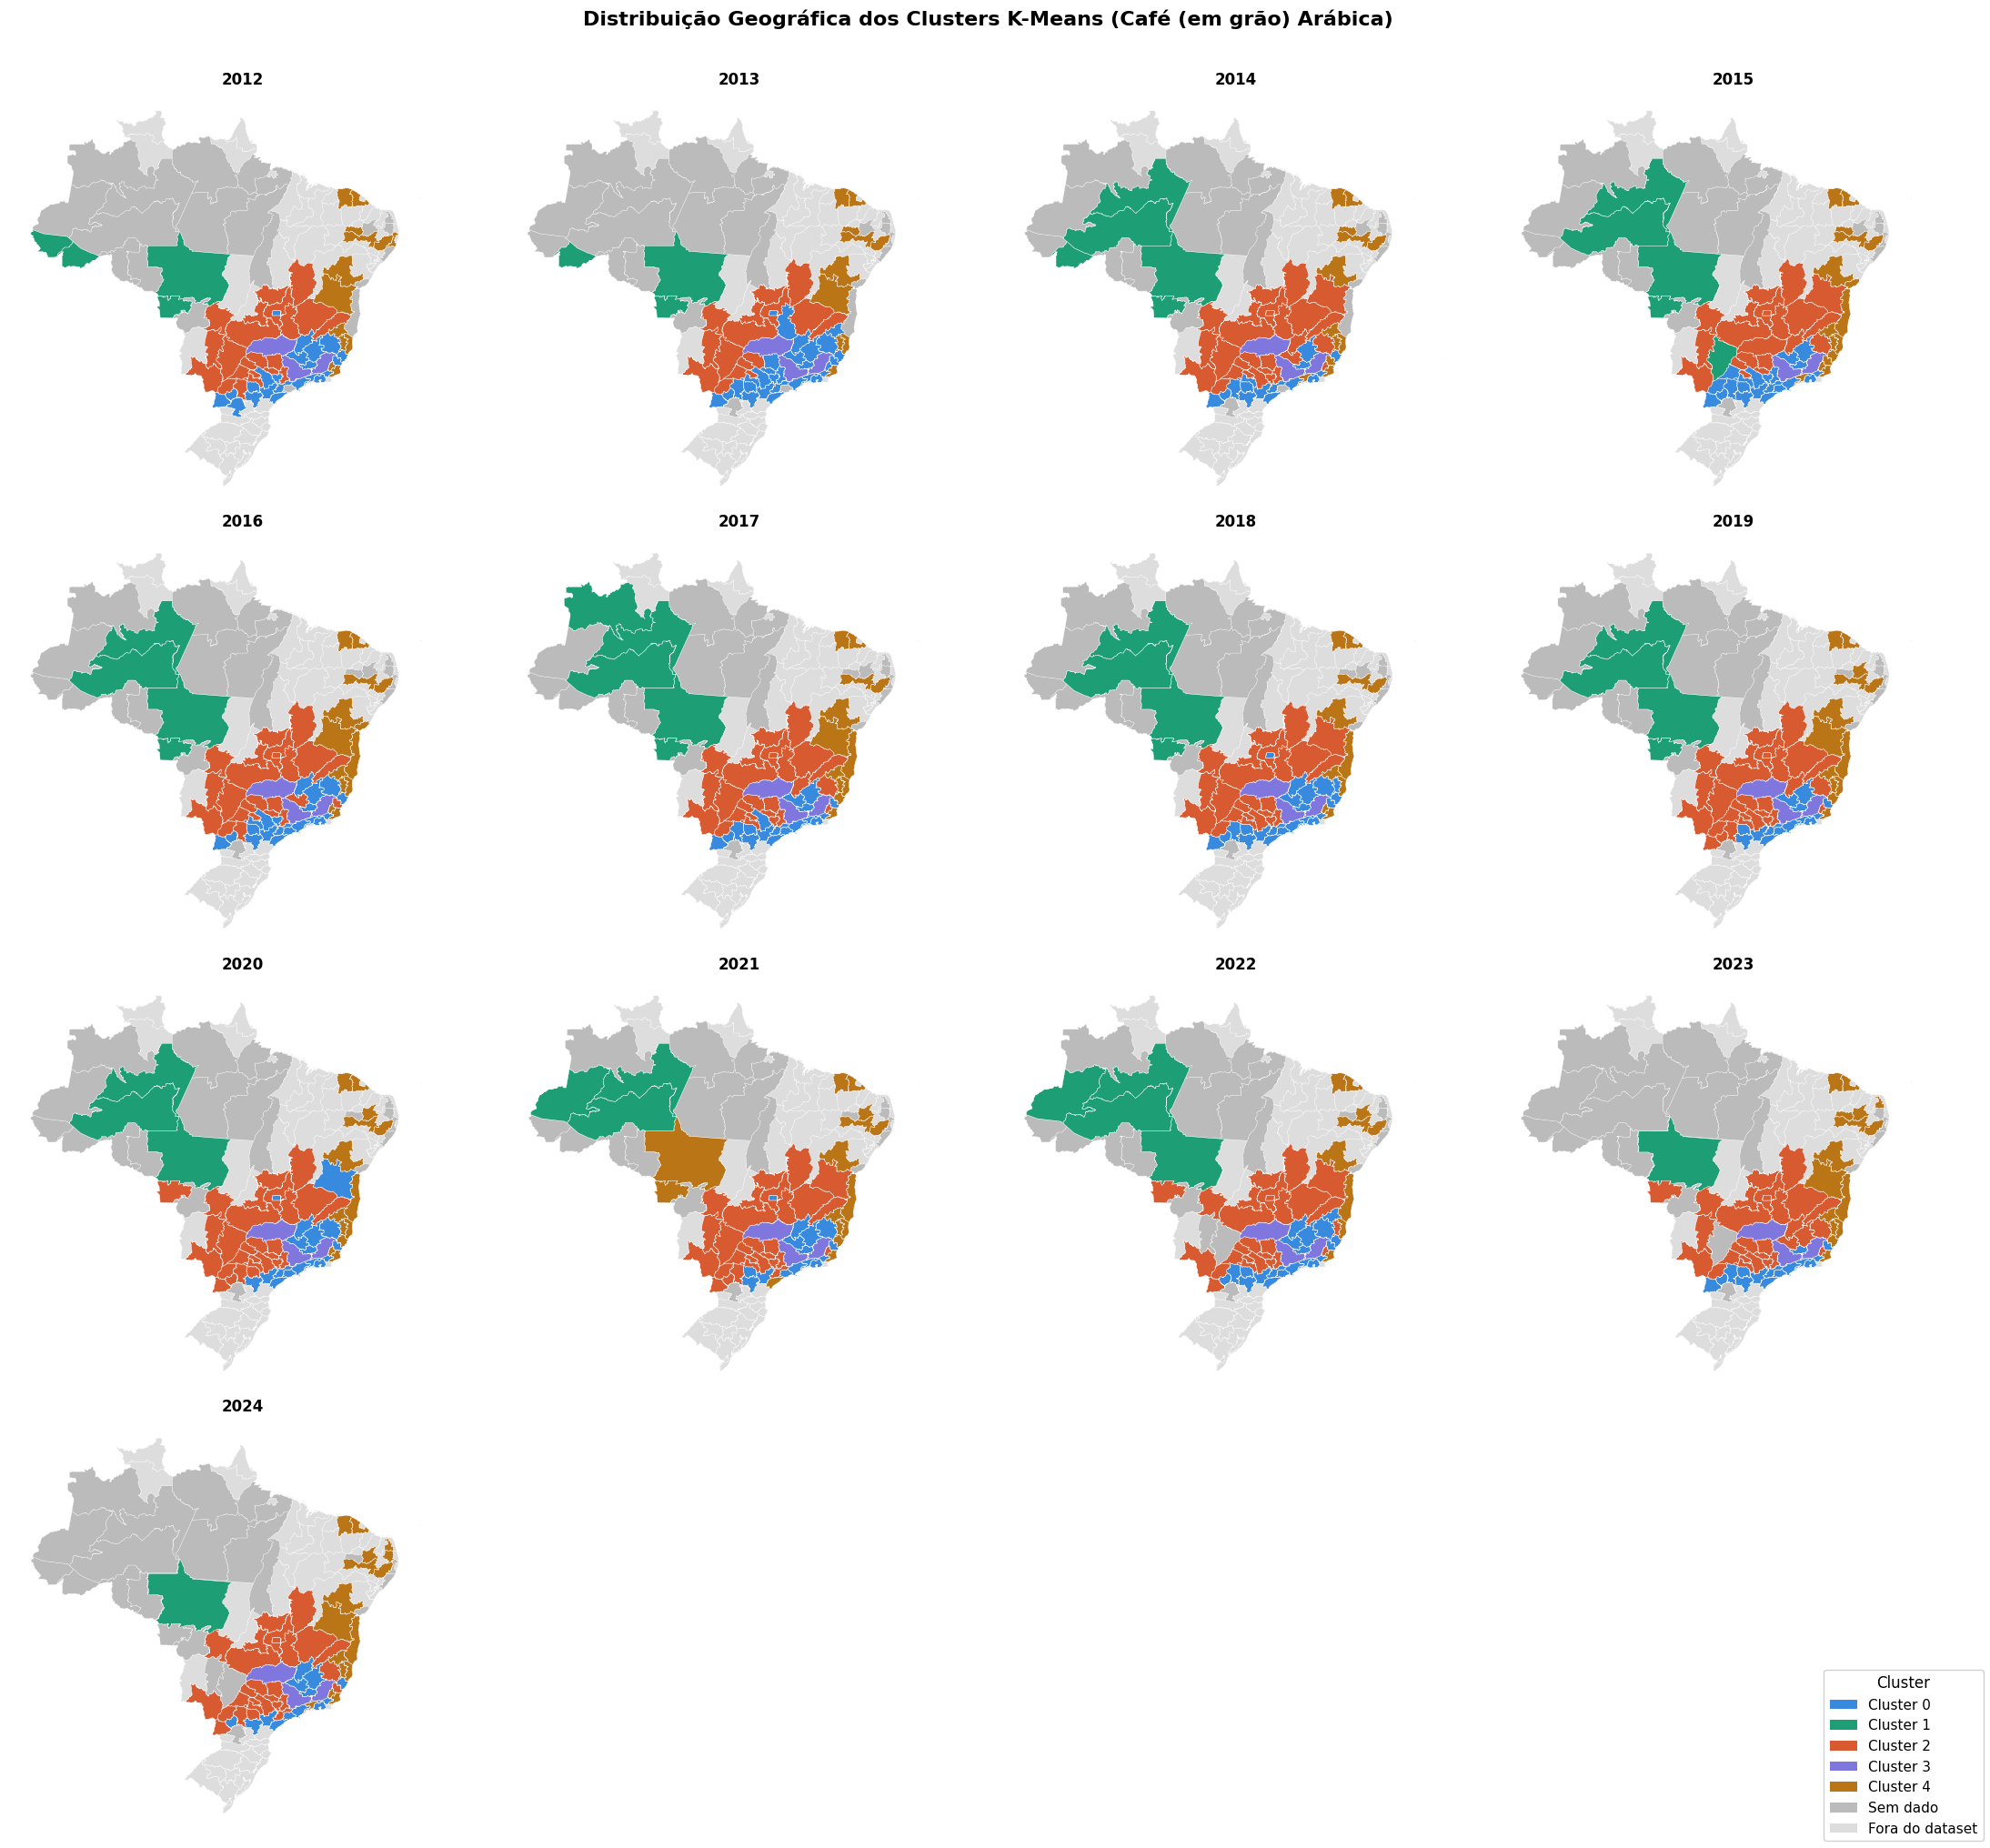

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Garante df_plot (se o kernel reiniciou)
if 'df_plot' not in globals():
    if 'df_final' not in globals():
        raise NameError("df_final não está definido. Re-execute as células anteriores até criar df_final.")
    required_cols = ['mesorregiao', 'ano', 'tipo', 'cluster']
    missing = [c for c in required_cols if c not in df_final.columns]
    if missing:
        raise KeyError(
            "df_final não tem as colunas necessárias para o mapa: " + ", ".join(missing) +
            ".\nDica: rode a célula que cria a coluna 'cluster' antes desta parte."
        )
    df_plot = df_final[required_cols].copy()
    df_plot['ano'] = pd.to_numeric(df_plot['ano'], errors='coerce')
    df_plot['cluster'] = pd.to_numeric(df_plot['cluster'], errors='coerce')
    df_plot = df_plot.dropna(subset=['ano', 'cluster'])
    df_plot['ano'] = df_plot['ano'].astype(int)
    df_plot['cluster'] = df_plot['cluster'].astype(int)

caminho_shapefile = "dados-brutos/centroides/BR_Mesorregioes_2022/BR_Mesorregioes_2022.shp"
gdf = gpd.read_file(caminho_shapefile)
gdf["mesorregiao"] = gdf["NM_MESO"] + " (" + gdf["SIGLA_UF"] + ")"

# Cores fixas para 5 clusters (0 a 4)
cores_mapa = {0: "#378ADD", 1: "#1D9E75", 2: "#D85A30", 3: "#7F77DD", 4: "#BA7517"}

tipos = pd.Series(df_plot["tipo"]).dropna().unique()
if len(tipos) == 0:
    raise ValueError("df_plot não tem valores válidos em 'tipo'.")
tipo_ref = tipos[0]

anos_mapa = sorted(pd.Series(df_plot.loc[df_plot["tipo"] == tipo_ref, "ano"]).dropna().unique())
if len(anos_mapa) == 0:
    raise ValueError(f"Não há anos para tipo={tipo_ref!r} em df_plot.")

n_cols = 4
n_rows = -(-len(anos_mapa) // n_cols)  # ceil
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

regioes_no_dataset = set(pd.Series(df_plot["mesorregiao"]).dropna().unique())

for idx, ano in enumerate(anos_mapa):
    ax = axes[idx]
    df_ano = df_plot[(df_plot["ano"] == ano) & (df_plot["tipo"] == tipo_ref)][["mesorregiao", "cluster"]]
    gdf_ano = gdf.merge(df_ano, on="mesorregiao", how="left")

    # Fora do dataset (não aparece em df_plot)
    gdf_ano[~gdf_ano["mesorregiao"].isin(regioes_no_dataset)].plot(
        ax=ax, color="#DDDDDD", edgecolor="white", linewidth=0.2
    )

    # No dataset, mas sem cluster (sem dado/NaN)
    gdf_ano[gdf_ano["mesorregiao"].isin(regioes_no_dataset) & gdf_ano["cluster"].isna()].plot(
        ax=ax, color="#BBBBBB", edgecolor="white", linewidth=0.2
    )

    # Clusters
    for cluster_id, cor in cores_mapa.items():
        subset = gdf_ano[gdf_ano["cluster"] == cluster_id]
        if not subset.empty:
            subset.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.3)

    ax.set_title(str(ano), fontsize=12, fontweight="bold")
    ax.axis("off")

# Desliga eixos que sobrarem
for idx in range(len(anos_mapa), len(axes)):
    axes[idx].axis("off")

legend_elements = [Patch(facecolor=cor, label=f"Cluster {k}") for k, cor in cores_mapa.items()]
legend_elements.append(Patch(facecolor="#BBBBBB", label="Sem dado"))
legend_elements.append(Patch(facecolor="#DDDDDD", label="Fora do dataset"))
fig.legend(
    handles=legend_elements, loc="lower right", fontsize=11,
    title="Cluster", title_fontsize=12, framealpha=0.9
 )

fig.suptitle(
    f"Distribuição Geográfica dos Clusters K-Means ({tipo_ref})",
    fontsize=16, fontweight="bold", y=1.01
 )
plt.tight_layout()
plt.show()

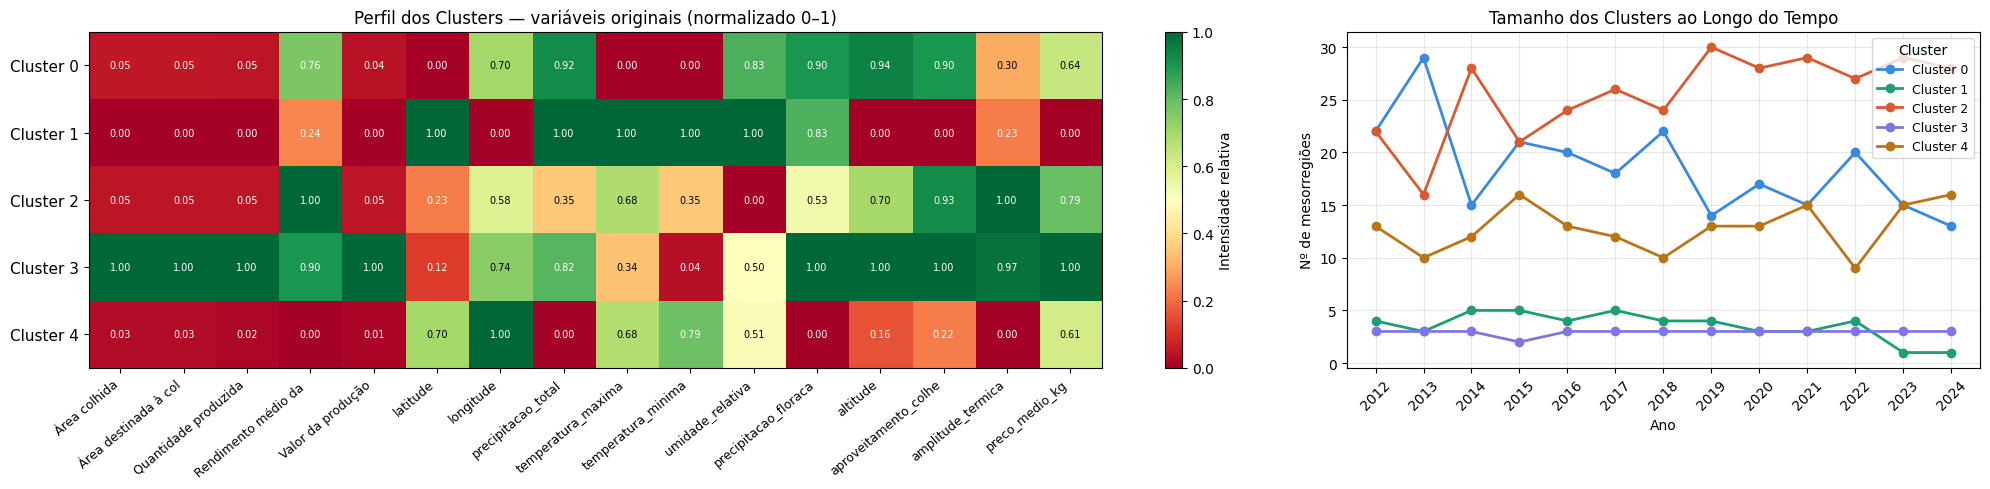


=== Perfil absoluto por cluster (médias) ===
cluster                          0          1             2             3            4
Área colhida          1.437872e+04      48.24  1.351744e+04  2.717417e+05      8289.05
Área destinada à col  1.439949e+04      49.35  1.355663e+04  2.717635e+05      8339.08
Quantidade produzida  2.090961e+07   51000.00  2.106723e+07  4.271176e+08   7972377.25
Rendimento médio da   1.470230e+03    1032.50  1.667050e+03  1.583080e+03       830.60
Valor da produção     1.829981e+08  209673.91  2.124660e+08  4.263856e+09  64133467.07
latitude             -2.222000e+01      -9.20 -1.927000e+01 -2.066000e+01       -13.14
longitude            -4.647000e+01     -61.10 -4.892000e+01 -4.556000e+01       -40.19
precipitacao_total    1.296770e+03    1350.31  8.937500e+02  1.223540e+03       645.94
temperatura_maxima    2.694000e+01      32.13  3.047000e+01  2.872000e+01        30.46
temperatura_minima    1.645000e+01      21.81  1.833000e+01  1.664000e+01        20.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'df_final' not in globals():
    raise NameError("df_final não está definido. Re-execute as células anteriores até criar df_final.")

# Se df_plot não existir (ex.: kernel reiniciado), cria a partir de df_final
if 'df_plot' not in globals():
    required_cols = ['mesorregiao', 'ano', 'tipo', 'cluster']
    missing = [c for c in required_cols if c not in df_final.columns]
    if missing:
        raise KeyError(
            "df_final não tem as colunas necessárias para os gráficos: " + ", ".join(missing) +
            ".\nDica: rode a célula que cria a coluna 'cluster' antes desta parte."
        )
    df_plot = df_final[required_cols].copy()
    df_plot['ano'] = pd.to_numeric(df_plot['ano'], errors='coerce')
    df_plot['cluster'] = pd.to_numeric(df_plot['cluster'], errors='coerce')
    df_plot = df_plot.dropna(subset=['ano', 'cluster'])
    df_plot['ano'] = df_plot['ano'].astype(int)
    df_plot['cluster'] = df_plot['cluster'].astype(int)

# feature_cols: colunas originais usadas para perfil (normalmente definidas na célula do KMeans)
if 'feature_cols' not in globals():
    numeric_cols = df_final.select_dtypes(include='number').columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in ['ano', 'cluster']]

cols_perfil = [c for c in feature_cols if c in df_final.columns]
if len(cols_perfil) == 0:
    raise ValueError("cols_perfil ficou vazio. Verifique 'feature_cols' e os tipos numéricos em df_final.")

# Perfil por cluster (para um tipo de café)
tipos = pd.Series(df_plot['tipo']).dropna().unique()
if len(tipos) == 0:
    raise ValueError("df_plot não tem valores válidos em 'tipo'.")
tipo_ref2 = tipos[0]

base = df_final[df_final['tipo'] == tipo_ref2].copy()
base = base[['mesorregiao', 'ano', 'tipo', 'cluster'] + cols_perfil].copy()
base['cluster'] = pd.to_numeric(base['cluster'], errors='coerce')
base = base.dropna(subset=['cluster'])
base['cluster'] = base['cluster'].astype(int).astype(str)

label_map = {c: c.split(' - ')[-1].split(' (')[0][:20] for c in cols_perfil}

perfil = base.groupby('cluster')[cols_perfil].mean(numeric_only=True)
perfil = perfil.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='all')
if perfil.shape[1] == 0:
    raise ValueError("Depois de remover colunas vazias, não sobrou nenhuma variável para o perfil.")

perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)
perfil_norm.columns = [label_map.get(c, c) for c in perfil_norm.columns]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [2, 1]})

# Heatmap de perfil
im = axes[0].imshow(perfil_norm.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_xticks(range(len(perfil_norm.columns)))
axes[0].set_xticklabels(perfil_norm.columns, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(len(perfil_norm.index)))
axes[0].set_yticklabels([f"Cluster {c}" for c in perfil_norm.index], fontsize=11)
axes[0].set_title('Perfil dos Clusters — variáveis originais (normalizado 0–1)', fontsize=12)
plt.colorbar(im, ax=axes[0], label='Intensidade relativa')

for i in range(len(perfil_norm.index)):
    for j in range(len(perfil_norm.columns)):
        val = float(perfil_norm.values[i, j])
        txt_color = 'white' if val > 0.75 or val < 0.25 else 'black'
        axes[0].text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7, color=txt_color)

# Tamanho dos clusters ao longo do tempo
contagem = (df_plot[df_plot['tipo'] == tipo_ref2]
            .groupby(['ano', 'cluster']).size().reset_index(name='count'))
contagem['cluster'] = pd.to_numeric(contagem['cluster'], errors='coerce')
contagem['ano'] = pd.to_numeric(contagem['ano'], errors='coerce')
contagem = contagem.dropna(subset=['cluster', 'ano'])
contagem['cluster'] = contagem['cluster'].astype(int)
contagem['ano'] = contagem['ano'].astype(int)

cores_plot = {0: '#378ADD', 1: '#1D9E75', 2: '#D85A30', 3: '#7F77DD', 4: '#BA7517'}
palette = list(cores_plot.values())
for cluster_id in sorted(contagem['cluster'].unique()):
    cor = cores_plot.get(cluster_id, palette[cluster_id % len(palette)])
    sub = contagem[contagem['cluster'] == cluster_id]
    if not sub.empty:
        axes[1].plot(sub['ano'], sub['count'], marker='o', color=cor,
                     label=f"Cluster {cluster_id}", linewidth=2)

axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nº de mesorregiões')
axes[1].set_title('Tamanho dos Clusters ao Longo do Tempo', fontsize=12)
axes[1].legend(title='Cluster', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(sorted(pd.Series(df_plot['ano']).dropna().unique()))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\n=== Perfil absoluto por cluster (médias) ===')
perfil_display = perfil.copy()
perfil_display.columns = [label_map.get(c, c) for c in perfil_display.columns]
print(perfil_display.round(2).T.to_string())